Antes de comenzar, recuerde ¿qu ́e tipo de im ́agenes son apropiadas para utilizar con
TH?, ¿qu ́e preprocesos ser ́ıan  ́utiles?, ¿qu ́e se obtiene (en el espacio transformado) al
aplicar TH a un punto?, ¿qu ́e particularidad presentan (en el espacio transformado)
los puntos colineales?, ¿qu ́e espera y qu ́e no, como resultado del proceso de la TH?
1. Estudie los par ́ametros de la funci ́on cv.HoughLines, y los formatos en los que
devuelve el resultado ([ρ,θ] o [ρ,θ, votes]).
Implemente un algoritmo que haga uso de esta funci ́on, debe permitir ajustar
el rango de los  ́angulos en la b ́usqueda de puntos colineales y el umbral para el
acumulador. Consejo: use trackbars.
2. Estudie la implementaci ́on de la TH probabil ́ıstica cv.HoughLinesP, sus par ́ametros
y el formato vectorial en el que devuelve los resultados.
Implemente un algoritmo que haga uso de esta funci ́on, debe permitir ajustar
los par ́ametros (minLineLength,maxLineGap) y el umbral para el acumulador.
Utilice ambas implementaciones con las im ́agenes ’letras1.tif’, ’letras2.tif’,
’snowman.png’ y ’building.jpg’.
Explique sus diferencias, ventajas y desventajas. ¿Cuando utilizar ́ıa uno y
cuando el otro?
3. [Opcional ]: implemente un algoritmo de post-proceso, que permita unir peque ̃nas
discontinuidades en puntos o segmentos colineales, a partir del resultado de la
transformada de hough. Se debe permitir el ajuste del par ́ametro de tolerancia.
¿Se le ocurre alguna alternativa en la que se aproveche el tono de gris o el color
de la imagen original?

In [1]:
import cv2
import numpy
import matplotlib.pyplot as plt

# parte 1: Analisis cv.HoughLines


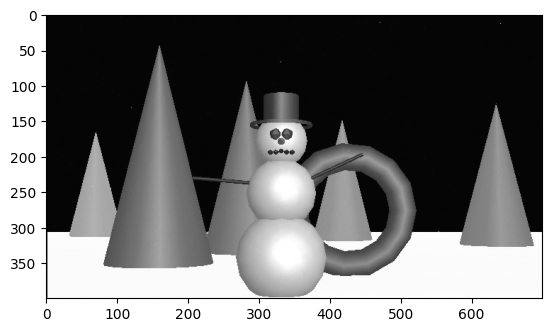

In [2]:
img = cv2.imread("../Imagenes_cursado/snowman.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap="gray")

Por cada punto X0, y0 vamos a tener una funcion en su representacion rho = x0*np.cos(theta) + y0*np.sin(theta)

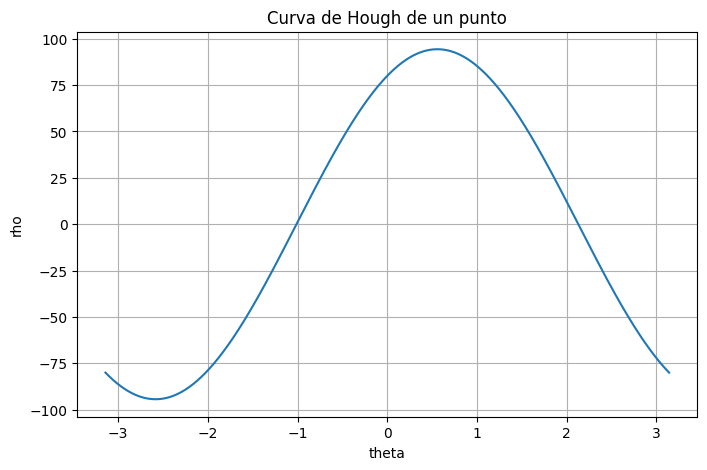

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Punto de imagen
x0 = 80
y0 = 50

# Angulos
theta = np.linspace(-np.pi, np.pi, 1000)

# Ecuacion de Hough
rho = x0*np.cos(theta) + y0*np.sin(theta)

plt.figure(figsize=(8,5))
plt.plot(theta, rho)

plt.xlabel("theta")
plt.ylabel("rho")
plt.title("Curva de Hough de un punto")
plt.grid()

plt.show()

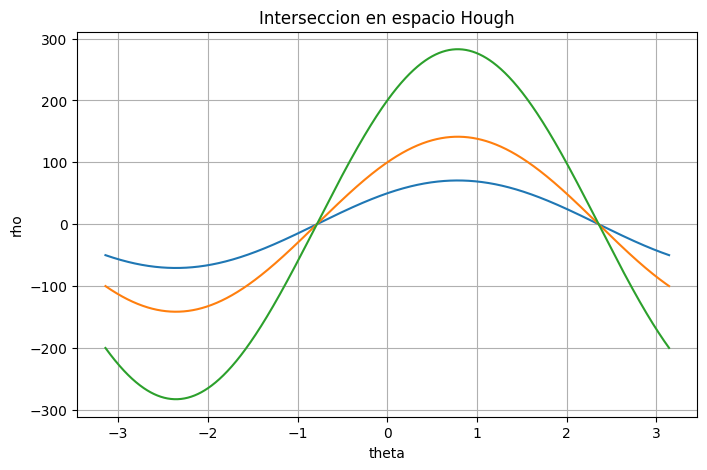

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Dos puntos de la misma recta
points = [
    (50, 50),
    (100, 100),
    (200,200)
]

theta = np.linspace(-np.pi, np.pi, 1000)

plt.figure(figsize=(8,5))

for x0, y0 in points:
    rho = x0*np.cos(theta) + y0*np.sin(theta)
    plt.plot(theta, rho)

plt.xlabel("theta")
plt.ylabel("rho")
plt.title("Interseccion en espacio Hough")
plt.grid()

plt.show()

Los puntos al alinearse se cruzan en una región de rho, theta. Son coordenadas de la recta colineal de esos puntos. Cuando se prueba para muchos puntos, donde hay regiones con MUCHAS acumulaciones es por hay colinealidad

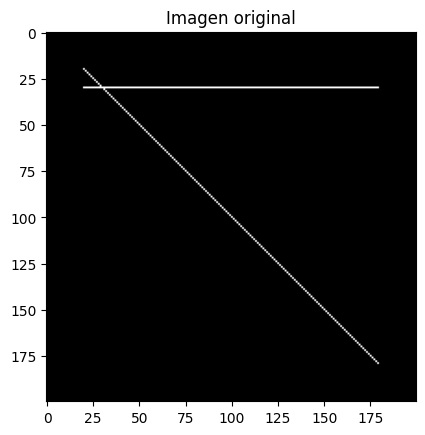

In [5]:
import numpy as np
import matplotlib.pyplot as plt

img = np.zeros((200,200))

# linea diagonal
for i in range(20,180):
    img[i,i] = 255
    img[30, i]=255

plt.imshow(img, cmap='gray')
plt.title("Imagen original")
plt.show()

Ahora vamos a utilizar la funcion houghlines

Crea una matriz A(rho, theta) llena de ceros


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_uint8 = img.astype(np.uint8)

lines = cv2.HoughLines(
    img_uint8,
    rho=1,
    theta=np.pi/180,
    threshold=80
)

print(lines)


[[[30.         1.5707964]]

 [[ 0.         2.3561945]]]


El constructor retorna los paramtreos de rho y theta que encuentra colinearidad.

Una vez identificado estos parametros, como rho = xcos(theta) + ysen(theta)


Parametros del constructor:
- treshold: cantidad minima de votos para ser consdierado una linea
- rho=



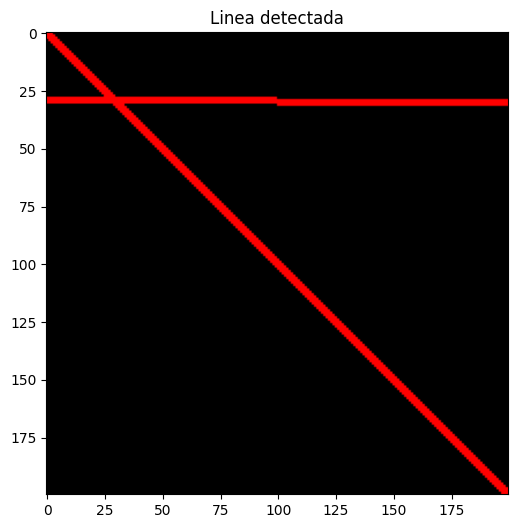

In [7]:
img_color = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2BGR)

for line in lines:
    rho, theta = line[0]

    a = np.cos(theta)
    b = np.sin(theta)

    x0 = a*rho
    y0 = b*rho

    x1 = int(x0 + 1000*(-b))
    y1 = int(y0 + 1000*(a))

    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))

    cv2.line(img_color, (x1,y1), (x2,y2), (0,0,255), 2)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
plt.title("Linea detectada")
plt.show()

# parte 1:


Vamos a intentar entender como funciona :)

Parametros a variar:
- Threshold: cantidad de aceptados para definir si la interseccion forma una recta colineal o no.
- theta min y thtea max es para identificar cierto tipo de rectas (por ejemplo calles verticales)

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# img debe existir previamente
# por ejemplo:
img = cv2.imread("../Imagenes_cursado/snowman.png", cv2.IMREAD_GRAYSCALE)

def hough_interactivo(threshold=80,theta_min=0,theta_max=180):

    if len(img.shape) == 2:
        gray = img.copy()
        draw = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    else:
        draw = img.copy()
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 50, 150) #hacemos primero los bordes con

    # conversión a radianes 
    theta_min_rad = np.deg2rad(theta_min) #podria no estar esto
    theta_max_rad = np.deg2rad(theta_max)
    theta_step = np.pi / 180

    # generar conjunto de ángulos permitido
    thetas = np.arange(theta_min_rad, theta_max_rad, theta_step)

    # acumulador manual usando OpenCV HoughLines

    lines = cv2.HoughLines(
        edges,
        rho=1,
        theta=theta_step,
        threshold=threshold
    )

    if lines is not None:
        for line in lines:
            rho, theta = line[0]
            if theta < theta_min_rad or theta > theta_max_rad:
                continue
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * ( a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * ( a))
            cv2.line(draw, (x1,y1), (x2,y2), (0,0,255), 2)

    # mostrar
    plt.figure(figsize=(14,6))

    plt.subplot(1,2,1)
    plt.imshow(edges, cmap='gray')
    plt.title("Bordes (Canny)")
    plt.axis("off")

    plt.subplot(1,2,2)

    if len(img.shape) == 2:
        plt.imshow(cv2.cvtColor(draw, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(cv2.cvtColor(draw, cv2.COLOR_BGR2RGB))

    plt.title(
        f"HoughLines\nthreshold={threshold} | theta=[{theta_min},{theta_max}]"
    )

    plt.axis("off")

    plt.show()


interact(
    hough_interactivo,

    threshold=IntSlider(
        min=1,
        max=300,
        step=1,
        value=80,
        description='threshold'
    ),

    theta_min=IntSlider(
        min=0,
        max=179,
        step=1,
        value=0,
        description='θ min'
    ),

    theta_max=IntSlider(
        min=1,
        max=180,
        step=1,
        value=180,
        description='θ max'
    )
);

interactive(children=(IntSlider(value=80, description='threshold', max=300, min=1), IntSlider(value=0, descrip…

# Parte 2

En vez de buscar lineas busca segmentos y devuelve las coordenadas. Misma idea de los votos.


In [9]:
def hough_p_interactivo(
    threshold=80,
    minLineLength=50,
    maxLineGap=10
):

    gray = img.copy()
    edges = cv2.Canny(gray, 50, 150)
    draw = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi/180,
        threshold=threshold,
        minLineLength=minLineLength,
        maxLineGap=maxLineGap
    )

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]

            cv2.line(
                draw,
                (x1, y1),
                (x2, y2),
                (0, 0, 255),
                2
            )

    plt.figure(figsize=(14,6))

    plt.subplot(1,2,1)
    plt.imshow(edges, cmap='gray')
    plt.title("Bordes (Canny)")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(draw, cv2.COLOR_BGR2RGB))
    plt.title(
        f"HoughLinesP\nthreshold={threshold} | "
        f"minLen={minLineLength} | maxGap={maxLineGap}"
    )
    plt.axis("off")

    plt.show()

In [10]:
interact(
    hough_p_interactivo,

    threshold=IntSlider(
        min=1,
        max=300,
        step=1,
        value=80,
        description='threshold'
    ),

    minLineLength=IntSlider(
        min=1,
        max=300,
        step=1,
        value=50,
        description='minLen'
    ),

    maxLineGap=IntSlider(
        min=0,
        max=50,
        step=1,
        value=10,
        description='maxGap'
    )
)

interactive(children=(IntSlider(value=80, description='threshold', max=300, min=1), IntSlider(value=50, descri…

<function __main__.hough_p_interactivo(threshold=80, minLineLength=50, maxLineGap=10)>